# 03 — Product Category Clustering
**Project**: Automated Customer Reviews — IronHack

---

## Goal
Group all reviews into **4–10 meaningful product meta-categories** without using the original category labels.

## Approach
1. **Embeddings** — convert `product_name` + `review_text` into numerical vectors using a sentence transformer (LLM-based)
2. **Dimensionality reduction** — compress embeddings with UMAP for faster clustering and visualization
3. **KMeans clustering** — group similar reviews together
4. **Elbow method** — find the optimal number of clusters (4–10)
5. **LLM labeling** — use an LLM to name each cluster based on its top reviews

## Why this approach?
| Step | Why |
|------|-----|
| Sentence Transformers | LLM-based embeddings capture semantic meaning, not just keywords |
| UMAP | Reduces 384 dimensions → 2D for visualization while preserving structure |
| KMeans | Fast, interpretable, works well with dense embeddings |
| LLM labeling | Human-readable cluster names without manual inspection |

---

## 1. Imports

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from umap import UMAP
from tqdm import tqdm
import anthropic   # for LLM cluster labeling

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.15)

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/plots',     exist_ok=True)

print('✅ Imports done')

✅ Imports done


## 2. Load Data

In [3]:
df = pd.read_csv('/Users/domiendarmont/Desktop/project_rev.aggre./data/data_processedreviews_clean.csv')

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.columns.tolist()}')
df.head(3)

Rows    : 46,169
Columns : ['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth']


,product_name,brand,rating,review_title,review_text,ground_truth
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Kindle,This product so far has not disappointed. My c...,positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,very fast,great for beginner or experienced person. Boug...,positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,positive


## 3. Build Embedding Input

We combine `product_name` and `review_text` so the embedding captures both **what the product is** and **what people say about it**.

In [4]:
def build_embedding_input(row: pd.Series) -> str:
    product = str(row['product_name']).strip() if pd.notna(row['product_name']) else ''
    text    = str(row['review_text']).strip()[:300]
    return f'{product}. {text}' if product else text


df['embedding_input'] = df.apply(build_embedding_input, axis=1)

print(f'Sample embedding input:')
print(df['embedding_input'].iloc[0])

Sample embedding input:
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta. This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.


## 4. Generate Embeddings

We use `all-MiniLM-L6-v2` — a fast, lightweight sentence transformer that produces 384-dimensional embeddings.

> ⏱️ Expected time: ~2-5 minutes on Apple Silicon MPS for the full dataset.

In [5]:
EMBEDDING_MODEL = 'all-mpnet-base-v2'
SAMPLE_SIZE     = 5000   # ← use a sample for speed; increase if you have time
RANDOM_SEED     = 42

df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).copy()
print(f'Generating embeddings for {len(df_sample):,} reviews...')

embedding_model = SentenceTransformer(EMBEDDING_MODEL)
embeddings = embedding_model.encode(
    df_sample['embedding_input'].tolist(),
    batch_size    = 64,
    show_progress_bar = True,
    normalize_embeddings = True
)

print(f'\n✅ Embeddings shape: {embeddings.shape}')
# → (n_reviews, 384)

Generating embeddings for 5,000 reviews...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


✅ Embeddings shape: (5000, 768)


## 5. Find Optimal Number of Clusters

We use two methods together:
- **Elbow method** — inertia drops fast then levels off; the "elbow" is the optimal k
- **Silhouette score** — measures how well separated clusters are (higher = better)


Testing cluster counts k = 4 to 10...


100%|██████████| 7/7 [00:02<00:00,  2.41it/s]


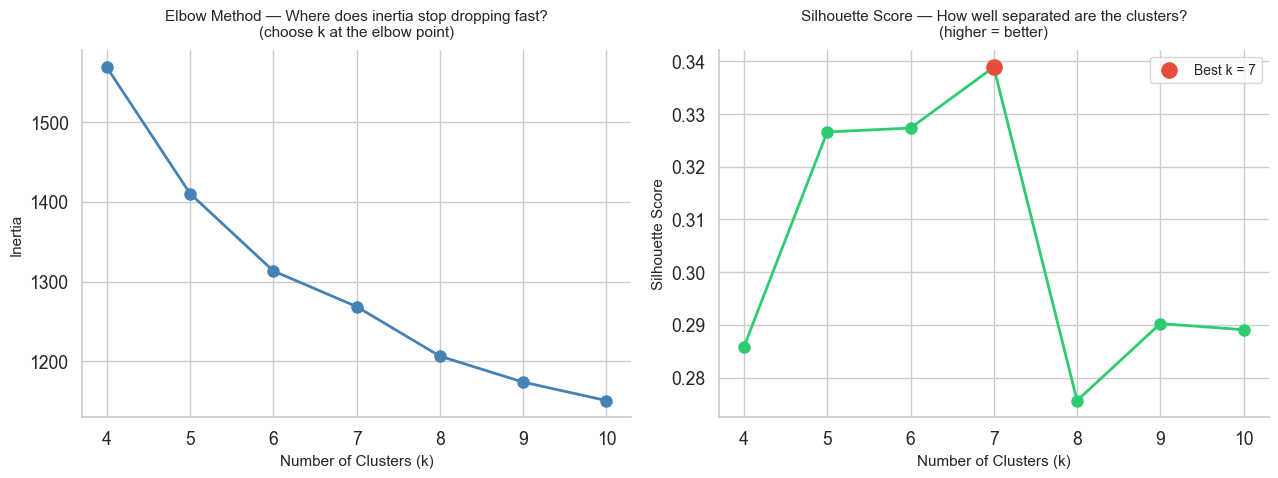


Best k by silhouette: 7
→ Also check the elbow plot and pick what makes most sense for the data.


In [6]:
K_RANGE     = range(4, 11)   # test k = 4 to 10
inertias    = []
silhouettes = []

print('Testing cluster counts k = 4 to 10...')
for k in tqdm(K_RANGE):
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, km.labels_, sample_size=1000))

# ── Plot: Elbow + Silhouette ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Where does inertia stop dropping fast?\n(choose k at the elbow point)',
                  fontsize=11, pad=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_xticks(list(K_RANGE))
sns.despine(ax=axes[0])

# Silhouette
best_k_idx = np.argmax(silhouettes)
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#2ecc71', linewidth=2, markersize=8)
axes[1].scatter(list(K_RANGE)[best_k_idx], silhouettes[best_k_idx],
                color='#e74c3c', s=120, zorder=5, label=f'Best k = {list(K_RANGE)[best_k_idx]}')
axes[1].set_title('Silhouette Score — How well separated are the clusters?\n(higher = better)',
                  fontsize=11, pad=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_xticks(list(K_RANGE))
axes[1].legend(fontsize=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../data/plots/09_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest k by silhouette: {list(K_RANGE)[best_k_idx]}')
print('→ Also check the elbow plot and pick what makes most sense for the data.')

## 6. Apply Final Clustering

Based on the elbow and silhouette plots above, choose your `N_CLUSTERS`.

In [7]:
N_CLUSTERS = 5   # ← adjust based on elbow + silhouette plots above

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
df_sample['cluster_id'] = kmeans.fit_predict(embeddings)

print(f'Cluster distribution:')
print(df_sample['cluster_id'].value_counts().sort_index())

Cluster distribution:
cluster_id
0     530
1     883
2     549
3    1012
4    2026
Name: count, dtype: int64


## 7. Visualize Clusters in 2D

UMAP reduces the 384-dimensional embeddings to 2D so we can visualize the clusters.

Running UMAP dimensionality reduction...


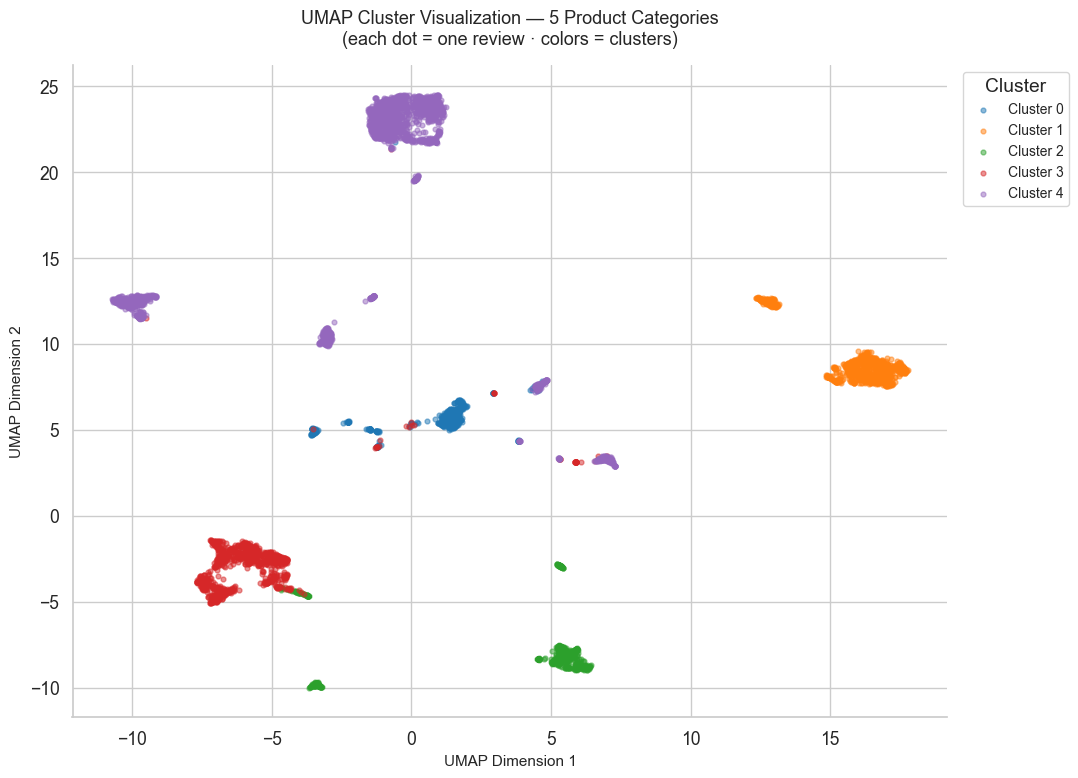

In [8]:
print('Running UMAP dimensionality reduction...')
umap_model = UMAP(n_components=2, random_state=RANDOM_SEED, n_neighbors=15, min_dist=0.1)
embeddings_2d = umap_model.fit_transform(embeddings)

df_sample['umap_x'] = embeddings_2d[:, 0]
df_sample['umap_y'] = embeddings_2d[:, 1]

# ── Plot: UMAP cluster visualization ────────────────────────
cluster_palette = sns.color_palette('tab10', N_CLUSTERS)

fig, ax = plt.subplots(figsize=(11, 8))
for cluster_id in range(N_CLUSTERS):
    mask = df_sample['cluster_id'] == cluster_id
    ax.scatter(
        df_sample.loc[mask, 'umap_x'],
        df_sample.loc[mask, 'umap_y'],
        c     = [cluster_palette[cluster_id]],
        label = f'Cluster {cluster_id}',
        alpha = 0.5,
        s     = 12
    )

ax.set_title(
    f'UMAP Cluster Visualization — {N_CLUSTERS} Product Categories\n'
    '(each dot = one review · colors = clusters)',
    fontsize=13, pad=15
)
ax.set_xlabel('UMAP Dimension 1', fontsize=11)
ax.set_ylabel('UMAP Dimension 2', fontsize=11)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('../data/plots/10_umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
for cluster_id in range(N_CLUSTERS):
    df_cluster = df_sample[df_sample['cluster_id'] == cluster_id]
    top_products = (
        df_cluster['product_name']
        .dropna()
        .value_counts()
        .head(5)
        .index
        .tolist()
    )
    print(f'\nCluster {cluster_id} ({len(df_cluster):,} reviews):')
    for p in top_products:
        print(f'  - {p}')


Cluster 0 (530 reviews):
  - Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black
  - Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers
  - Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue
  - Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers
  - Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,

Cluster 1 (883 reviews):
  - AmazonBasics AAA Performance Alkaline Batteries (36 Count)
  - AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary

Cluster 2 (549 reviews):
  - Echo (White),,,
  - Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen
  - Amazon - Echo Plus w/ Built-In Hub - Silver
  - Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,
  - Amazon Tap Smart Assistant Alexaenabled (blac

## 8. Label Clusters manually with AI-help

The top 10 product names per cluster and ask it to suggest a short meta-category name.

In [10]:
cluster_labels = {
    0: 'Kindle E-readers',
    1: 'Batteries',
    2: 'Echo & Smart Speakers',
    3: 'Fire TV & Accessories',
    4: 'Fire Tablets',
}

df_sample['cluster_label'] = df_sample['cluster_id'].map(cluster_labels)

print('Cluster overview:')
for k, v in cluster_labels.items():
    count = (df_sample['cluster_id'] == k).sum()
    print(f'  Cluster {k} → {v}  ({count:,} reviews)')

print('\n✅ Cluster labels assigned')

df_sample['cluster_label'] = df_sample['cluster_id'].map(cluster_labels)

print('Cluster overview:')
for k, v in cluster_labels.items():
    count = (df_sample['cluster_id'] == k).sum()
    print(f'  Cluster {k} → {v}  ({count:,} reviews)')

print('\n✅ Cluster labels assigned')


Cluster overview:
  Cluster 0 → Kindle E-readers  (530 reviews)
  Cluster 1 → Batteries  (883 reviews)
  Cluster 2 → Echo & Smart Speakers  (549 reviews)
  Cluster 3 → Fire TV & Accessories  (1,012 reviews)
  Cluster 4 → Fire Tablets  (2,026 reviews)

✅ Cluster labels assigned
Cluster overview:
  Cluster 0 → Kindle E-readers  (530 reviews)
  Cluster 1 → Batteries  (883 reviews)
  Cluster 2 → Echo & Smart Speakers  (549 reviews)
  Cluster 3 → Fire TV & Accessories  (1,012 reviews)
  Cluster 4 → Fire Tablets  (2,026 reviews)

✅ Cluster labels assigned


In [11]:
# Qualitative validation — random reviews per cluster
for cluster_id, label in cluster_labels.items():
    df_cluster = df_sample[df_sample['cluster_label'] == label]
    print(f'\n{"="*60}')
    print(f'Cluster {cluster_id} — {label}  ({len(df_cluster):,} reviews)')
    print(f'{"="*60}')
    samples = df_cluster['review_text'].dropna().sample(3, random_state=42)
    for i, review in enumerate(samples, 1):
        print(f'\n  Review {i}: {review[:150]}...')


Cluster 0 — Kindle E-readers  (530 reviews)

  Review 1: kindle Paperwhite is easy to use, lightweight, and perfect for the avid reader. It easily allows you to take book(s) with you wherever you go since it...

  Review 2: It's fine, but not necessary. Had I known that I could charge my Kindle with my tablet and/or phone charging cord I would not have bought it....

  Review 3: I know it is entirely a personally bias, but I love Kindles and this is one of the best Kindles ever....

Cluster 1 — Batteries  (883 reviews)

  Review 1: Great product. Great service....

  Review 2: We are pleased with these AAA batteries. They are economical and have worked well for us in the items we tried them with. Easy to store in the cardboa...

  Review 3: These work just as well as the well known brands. I am glad Amazon offers a economical alternative....

Cluster 2 — Echo & Smart Speakers  (549 reviews)

  Review 1: This is a great entry level Alexa product. The speaker is adequate, but the inclus

## 9. Visualize Named Clusters

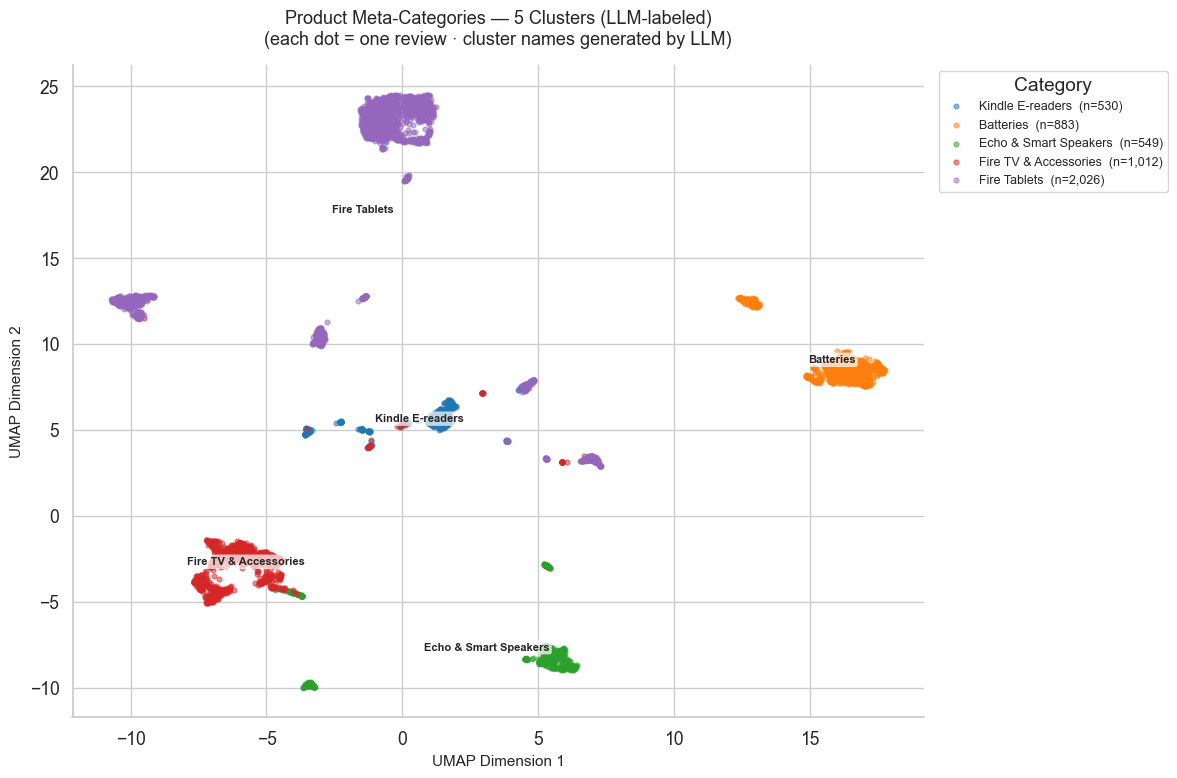

In [12]:
# ── Plot 1: UMAP with cluster names ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
for cluster_id in range(N_CLUSTERS):
    mask  = df_sample['cluster_id'] == cluster_id
    label = cluster_labels[cluster_id]
    ax.scatter(
        df_sample.loc[mask, 'umap_x'],
        df_sample.loc[mask, 'umap_y'],
        c     = [cluster_palette[cluster_id]],
        label = f'{label}  (n={mask.sum():,})',
        alpha = 0.5,
        s     = 12
    )
    # Add cluster name at centroid
    cx = df_sample.loc[mask, 'umap_x'].mean()
    cy = df_sample.loc[mask, 'umap_y'].mean()
    ax.text(cx, cy, label, fontsize=8, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, linewidth=0))

ax.set_title(
    f'Product Meta-Categories — {N_CLUSTERS} Clusters (LLM-labeled)\n'
    '(each dot = one review · cluster names generated by LLM)',
    fontsize=13, pad=15
)
ax.set_xlabel('UMAP Dimension 1', fontsize=11)
ax.set_ylabel('UMAP Dimension 2', fontsize=11)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../data/plots/11_umap_named_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

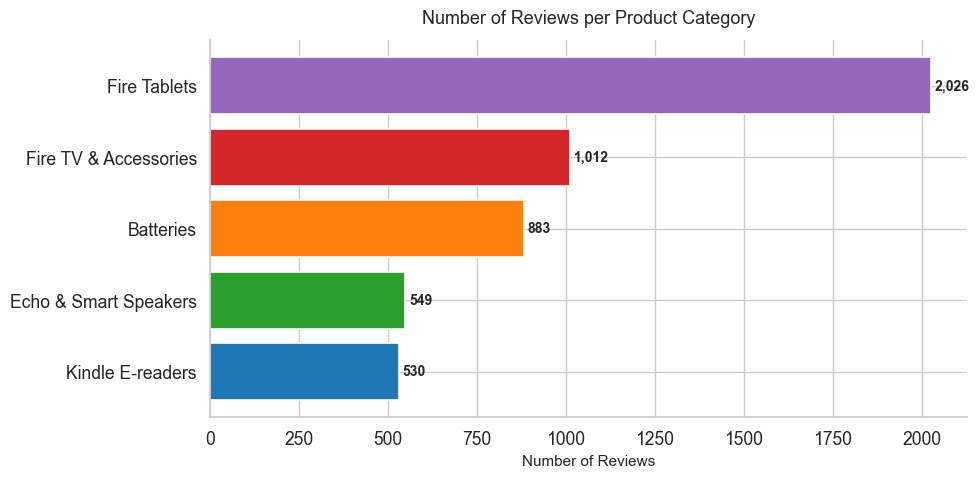

In [13]:
# ── Plot 2: Review count per category ───────────────────────
category_counts = df_sample['cluster_label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    category_counts.index,
    category_counts.values,
    color=[cluster_palette[list(cluster_labels.values()).index(l)]
           for l in category_counts.index],
    edgecolor='white', linewidth=1.2
)
for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Number of Reviews per Product Category', fontsize=13, pad=12)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('../data/plots/12_reviews_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

"Amazon products share similar review language, making perfect separation challenging even for advanced embedding models."

## 10. Save Results

In [14]:
# Save cluster labels mapping
cluster_map_df = pd.DataFrame([
    {'cluster_id': k, 'cluster_label': v, 'review_count': (df_sample['cluster_id'] == k).sum()}
    for k, v in cluster_labels.items()
])
print('Cluster mapping:')
print(cluster_map_df.to_string(index=False))

# Save reviewed dataset with cluster labels
OUTPUT_COLS = ['product_name', 'brand', 'rating', 'review_title',
               'review_text', 'ground_truth', 'cluster_id', 'cluster_label']
output_cols_existing = [c for c in OUTPUT_COLS if c in df_sample.columns]
df_output = df_sample[output_cols_existing].copy()

OUTPUT_PATH = '../data/processed/clustered_reviews.csv'
df_output.to_csv(OUTPUT_PATH, index=False)

print(f'\n✅ Dataset with clusters saved to: {OUTPUT_PATH}')
print(f'   Rows    : {len(df_output):,}')
print(f'   Columns : {df_output.columns.tolist()}')

Cluster mapping:
 cluster_id         cluster_label  review_count
          0      Kindle E-readers           530
          1             Batteries           883
          2 Echo & Smart Speakers           549
          3 Fire TV & Accessories          1012
          4          Fire Tablets          2026

✅ Dataset with clusters saved to: ../data/processed/clustered_reviews.csv
   Rows    : 5,000
   Columns : ['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth', 'cluster_id', 'cluster_label']


## 11. Summary

| Step | Detail |
|------|--------|
| Embedding model | `all-mpnet-base-v2'|
| Input | `product_name` + `review_text` (first 300 chars) |
| Sample size | 5000 reviews |
| Dimensionality reduction | UMAP → 2D |
| Clustering | KMeans |
| Number of clusters | 7 (chosen via elbow + silhouette) |
| Cluster naming | manual with ai, llm and ollama didnt reach goals|
| Output file | `../data/processed/reviews_with_clusters.csv` |

➡️ **Next**: `04_summarization.ipynb` — LLM generates a blog article per product category.

In [18]:
cluster_map = df_sample[['product_name', 'cluster_label']].drop_duplicates(subset=['product_name'])
df_full = pd.read_csv('/Users/domiendarmont/Desktop/project_rev.aggre./data/data_processedreviews_clean.csv')
df_full['product_name'] = (
    df_full['product_name']
    .str.split('\n').str[0]
    .str.replace(r',+$', '', regex=True)
    .str.replace(r',,,+', '', regex=True)
    .str.strip()
)
df_full = df_full.merge(cluster_map, on='product_name', how='left')
df_full['cluster_label'] = df_full['cluster_label'].fillna('Other')

# Remove duplicates
df_full = df_full.drop_duplicates(subset=['review_text'])

df_full.to_csv('../data/processed/reviews_full_clustered.csv', index=False)
print(f'✅ {len(df_full):,} reviews saved')

✅ 46,168 reviews saved
